In [26]:
import json
cancers = ['ccRCC', 'Melanoma', 'NSCLC']
MetaScore_all = {}

def load_metascore(cancer):
    file_path = f"MetaScore_{cancer}.json"
    with open(file_path, 'r', encoding='utf-8') as f:
        MetaScore = json.load(f)
    return MetaScore

MetaScore_all = {
    'ccRCC': load_metascore('ccRCC'),
    'Melanoma': load_metascore('Melanoma'),
    'NSCLC': load_metascore('NSCLC')
}

✅ Saved: weighted_composite_scores_multi.pdf


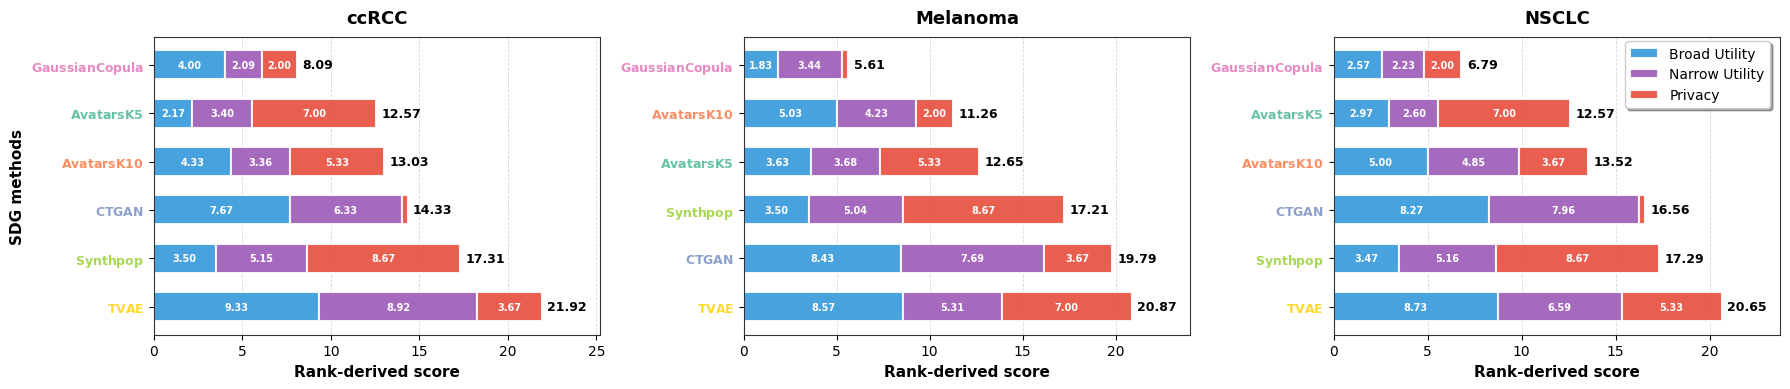

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",  # greenish
    "Avatars K10": "#fc8d62",  # orange
    "CTGAN": "#8da0cb",  # blue
    "Gaussian Copula": "#e78ac3",  # pink
    "Synthpop": "#a6d854",  # lime
    "TVAE": "#ffd92f",  # yellow
}

COMPONENT_COLORS = {
    'Broad Utility': '#3498db',    # blue
    'Narrow Utility': '#9b59b6',   # purple
    'Privacy': '#e74c3c'           # red
}


def plot_combined_weighted_composite_scores(
    MetaScore_all: dict,
    broad_weight: float = 0.3,
    narrow_weight: float = 0.5,
    privacy_weight: float = 0.2,
    figsize: tuple = (18, 5),
    save_path: str = None,
    orientation: str = 'horizontal',
):
    """
    Plot weighted composite scores for multiple datasets as subplots.
    
    Args:
        MetaScore_all: dict with dataset names as keys and MetaScore dicts as values
                      e.g., {'ccRCC': MetaScore1, 'Melanoma': MetaScore2, 'NSCLC': MetaScore3}
        broad_weight: weight for broad utility (default: 0.3)
        narrow_weight: weight for narrow utility (default: 0.5)
        privacy_weight: weight for privacy (default: 0.2)
        figsize: figure size (default: (18, 5) for 3 subplots)
        save_path: optional path to save figure
        orientation: 'horizontal' or 'vertical' (default: 'horizontal')
    """
    # Apply style
    try:
        plt.style.use(["science", "nature", "notebook"])
    except Exception:
        pass
    
    plt.rcParams.update({
        'text.usetex': False,
        'axes.edgecolor': '#333333',
        'xtick.minor.visible': False,
        'ytick.minor.visible': False,
        'xtick.top': False,
        'ytick.right': False,
    })
    
    # Create figure with subplots
    n_datasets = len(MetaScore_all)
    fig, axes = plt.subplots(1, n_datasets, figsize=figsize)
    
    # If only one dataset, make axes iterable
    if n_datasets == 1:
        axes = [axes]
    
    results_all = {}
    
    # Plot each dataset
    for idx, (dataset_name, MetaScore) in enumerate(MetaScore_all.items()):
        ax = axes[idx]
        
        # Create DataFrame from MetaScore
        df = pd.DataFrame(MetaScore)
        
        # Calculate weighted components
        df_final = pd.DataFrame()
        
        # Broad Utility = (Univariate + Bivariate) * broad_weight / 2
        broad_weighted = broad_weight * (1/2)
        df_final['Broad Utility'] = (
            df['UnivariateScore'] * broad_weighted + 
            df['BivariateScore'] * broad_weighted
        )
        
        # Narrow Utility = (DGE + GSEA + ssGSEA + Cell + Survival) * narrow_weight / 5
        narrow_weighted = narrow_weight * (1/5)
        narrow_metrics = ['DGE', 'GSEA', 'ssGSEA', 'Cell Deconvolution', 'Survival Analysis']
        df_final['Narrow Utility'] = df[narrow_metrics].sum(axis=1) * narrow_weighted
        
        # Privacy = Privacy * privacy_weight
        df_final['Privacy'] = df['Privacy'] * privacy_weight
        
        # Sort by total score
        df_final['Total'] = df_final.sum(axis=1)
        df_final = df_final.sort_values('Total', ascending=(orientation == 'vertical')).drop(columns='Total')
        
        # Store results
        df_final['Total'] = df_final.sum(axis=1)
        results_all[dataset_name] = df_final.sort_values('Total', ascending=False)
        
        # Get dataset names and positions
        datasets = df_final.index.tolist()
        n_methods = len(datasets)
        
        if orientation == 'horizontal':
            # Horizontal bars
            y = np.arange(n_methods)
            height = 0.6
            left = np.zeros(n_methods)
            
            for component in ['Broad Utility', 'Narrow Utility', 'Privacy']:
                values = df_final[component].values
                color = COMPONENT_COLORS[component]
                
                bars = ax.barh(
                    y, 
                    values, 
                    height, 
                    left=left, 
                    label=component if idx == n_datasets - 1 else "",  # Only label in last subplot
                    color=color,
                    edgecolor='white',
                    linewidth=1.5,
                    alpha=0.9
                )
                
                # Add value labels on bars (only if segment is wide enough)
                for i, (bar, val) in enumerate(zip(bars, values)):
                    if val > 0.5:  # Only show label if segment is wide enough
                        ax.text(
                            left[i] + val / 2,
                            bar.get_y() + bar.get_height() / 2,
                            f'{val:.2f}',
                            ha='center',
                            va='center',
                            color='white',
                            fontsize=7,
                            fontweight='bold'
                        )
                
                left += values
            
            # Add total score at the end of each bar
            for i, total in enumerate(left):
                ax.text(
                    total + 0.3,
                    i,
                    f'{total:.2f}',
                    ha='left',
                    va='center',
                    color='black',
                    fontsize=9,
                    fontweight='bold'
                )
            
            # Styling
            ax.set_xlabel('Rank-derived score', fontsize=11, fontweight='bold')
            if idx == 0:  # Only show ylabel on first subplot
                ax.set_ylabel('SDG methods', fontsize=11, fontweight='bold')
            
            ax.set_title(
                f'{dataset_name}',
                fontsize=13,
                fontweight='bold',
                pad=10
            )
            
            # Y-axis: dataset names with colors
            ax.set_yticks(y)
            ax.set_yticklabels(
                [f"$\\mathbf{{{ds}}}$" for ds in datasets],
                fontsize=9
            )
            
            # Color y-tick labels according to dataset colors
            for i, (tick_label, dataset) in enumerate(zip(ax.get_yticklabels(), datasets)):
                color = DATASET_COLORS.get(dataset, '#333333')
                tick_label.set_color(color)
            
            # Grid
            ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)
            ax.set_axisbelow(True)
            
            # Set x-axis limit with padding for total labels
            ax.set_xlim(0, left.max() * 1.15)
            
        else:  # vertical
            x = np.arange(n_methods)
            width = 0.6
            bottom = np.zeros(n_methods)
            
            for component in ['Broad Utility', 'Narrow Utility', 'Privacy']:
                values = df_final[component].values
                color = COMPONENT_COLORS[component]
                
                bars = ax.bar(
                    x, 
                    values, 
                    width, 
                    bottom=bottom, 
                    label=component if idx == n_datasets - 1 else "",
                    color=color,
                    edgecolor='white',
                    linewidth=1.5,
                    alpha=0.9
                )
                
                # Add value labels on bars
                for i, (bar, val) in enumerate(zip(bars, values)):
                    if val > 0.5:
                        ax.text(
                            bar.get_x() + bar.get_width() / 2,
                            bottom[i] + val / 2,
                            f'{val:.2f}',
                            ha='center',
                            va='center',
                            color='white',
                            fontsize=7,
                            fontweight='bold'
                        )
                
                bottom += values
            
            # Add total score on top
            for i, total in enumerate(bottom):
                ax.text(
                    i,
                    total + 0.3,
                    f'{total:.2f}',
                    ha='center',
                    va='bottom',
                    color='black',
                    fontsize=9,
                    fontweight='bold'
                )
            
            # Styling
            if idx == 0:
                ax.set_ylabel('Rank-derived score', fontsize=11, fontweight='bold')
            ax.set_xlabel('SDG methods', fontsize=11, fontweight='bold')
            
            ax.set_title(
                f'{dataset_name}',
                fontsize=13,
                fontweight='bold',
                pad=10
            )
            
            # X-axis: dataset names with colors
            ax.set_xticks(x)
            ax.set_xticklabels(
                [f"$\\mathbf{{{ds}}}$" for ds in datasets],
                rotation=45,
                ha='right',
                fontsize=9
            )
            
            # Color x-tick labels
            for i, (tick_label, dataset) in enumerate(zip(ax.get_xticklabels(), datasets)):
                color = DATASET_COLORS.get(dataset, '#333333')
                tick_label.set_color(color)
            
            # Grid
            ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.5)
            ax.set_axisbelow(True)
            
            # Set y-axis limit
            ax.set_ylim(0, bottom.max() * 1.1)
    
    # Add legend to the right of the last subplot
    if orientation == 'horizontal':
        handles, labels = axes[-1].get_legend_handles_labels()
        fig.legend(
            handles, labels,
            loc='upper right',
            bbox_to_anchor=(0.99, 0.9),
            frameon=True,
            fontsize=10,
            fancybox=True,
            shadow=True
        )
    else:
        handles, labels = axes[-1].get_legend_handles_labels()
        fig.legend(
            handles, labels,
            loc='upper right',
            bbox_to_anchor=(0.5, 1.05),
            ncol=3,
            frameon=True,
            fontsize=10,
            fancybox=True,
            shadow=True
        )
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Saved: {save_path}")
    
    plt.show()
    plt.close()
    
    return fig, results_all


# Usage example:
# Plot and get results for all 3 datasets
fig, results_all = plot_combined_weighted_composite_scores(
    MetaScore_all=MetaScore_all,
    broad_weight=1/3,
    narrow_weight=1/3,
    privacy_weight=1/3,
    figsize=(18, 4),  # Wider figure for 3 subplots
    orientation='horizontal',
    save_path='weighted_composite_scores_multi.pdf'
)


In [13]:
MetaScore_all = {
    'ccRCC': load_metascore('ccRCC'),
    'Melanoma': load_metascore('Melanoma'),
    'NSCLC': load_metascore('NSCLC')
}

dfs = []
for cancer, meta_score in MetaScore_all.items():
    dfs.append(pd.DataFrame(meta_score))

In [14]:
df_combined = pd.concat(dfs, axis = 0)

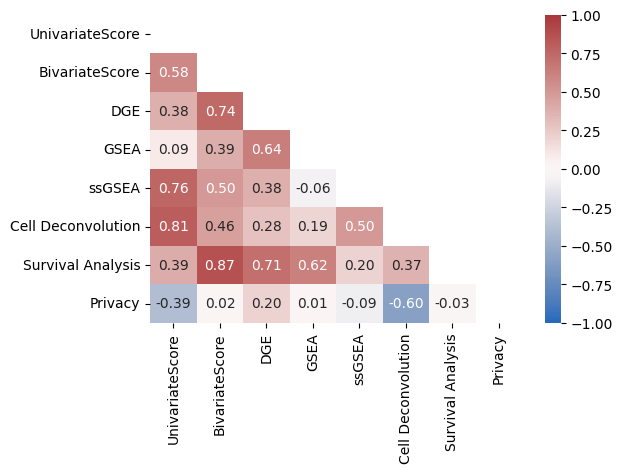

In [29]:
# Code tạo heatmap của bạn
corr = df_combined.corr(method='spearman')
mask = np.triu(corr)

# Lưu ý: đặt tên biến là 'ax' thay vì 'fig' để chuẩn xác hơn vì heatmap trả về Axes
plt.figure(figsize=(6, 4)) # Thiết lập kích thước bảng trước khi vẽ
ax = sns.heatmap(corr, mask=mask, cmap="vlag", vmin=-1, vmax=1, annot=True, fmt=".2f")

# --- LƯU ẢNH ---
# Cách 1: Lưu định dạng PNG (phổ biến)
# plt.savefig("correlation_heatmap.pdf", dpi=300, bbox_inches='tight')

# Cách 2: Lưu định dạng PDF (Vector - cực nét khi zoom, tốt nhất cho in ấn)
plt.savefig("correlation_heatmap.pdf", bbox_inches='tight')

plt.show()